# Retail Sales Dataset Visualization
This notebook loads the Kaggle Retail Sales dataset and performs exploratory data analysis and visualization steps as requested.

In [1]:
# Load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

data_path = "retail_sales_dataset.csv"
df = pd.read_csv(data_path)
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [2]:
# Basic exploration
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

display(df.head())
display(df.tail())
display(df.describe(include="all"))
print("Shape:", df.shape)
print("Missing values:\n", df.isna().sum())
df.info()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000,1000,1000.00000,1000,1000.000000,1000.000000,1000.000000
unique,NaN,NaN,1000,2,NaN,3,NaN,NaN,NaN
top,NaN,NaN,CUST001,Female,NaN,Clothing,NaN,NaN,NaN
freq,NaN,NaN,1,510,NaN,351,NaN,NaN,NaN
mean,500.500000,2023-07-03 00:25:55.200000256,NaN,NaN,41.39200,NaN,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,NaN,NaN,18.00000,NaN,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,NaN,NaN,29.00000,NaN,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,NaN,NaN,42.00000,NaN,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,NaN,NaN,53.00000,NaN,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,NaN,NaN,64.00000,NaN,4.000000,500.000000,2000.000000


Shape: (1000, 9)
Missing values:
 Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory us

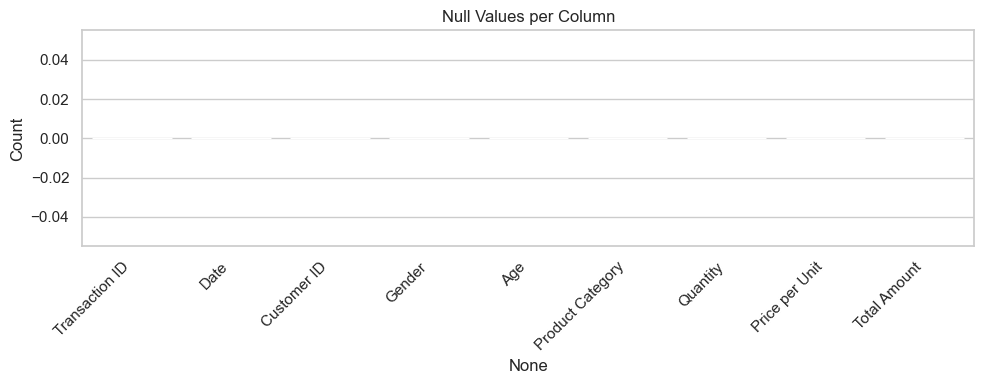

In [3]:
# Null values plot
null_counts = df.isna().sum()
plt.figure(figsize=(10, 4))
sns.barplot(x=null_counts.index, y=null_counts.values, color="steelblue")
plt.title("Null Values per Column")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_12964\179707799.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Gender", ax=axes[0], palette="Set2")
C:\Users\admin\AppData\Local\Temp\ipykernel_12964\179707799.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Product Category", ax=axes[1], palette="Set3")


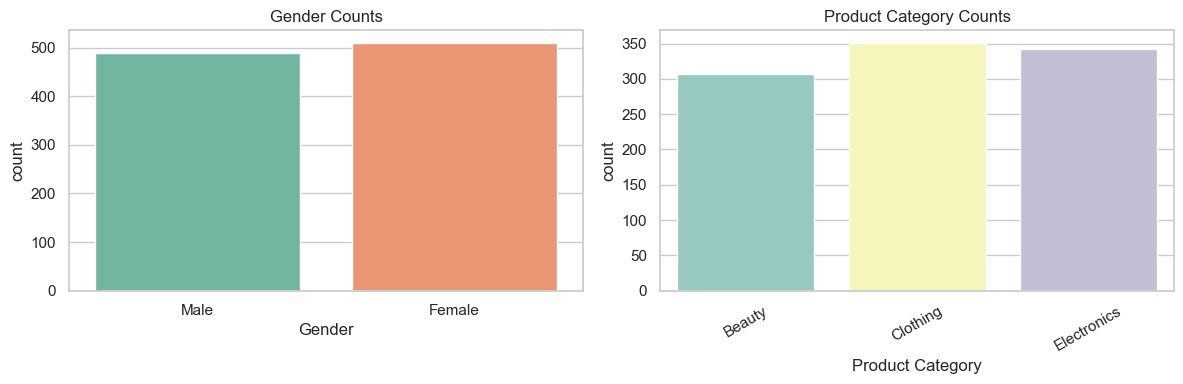

In [4]:
# Categorical count plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="Gender", ax=axes[0], palette="Set2")
axes[0].set_title("Gender Counts")
sns.countplot(data=df, x="Product Category", ax=axes[1], palette="Set3")
axes[1].set_title("Product Category Counts")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

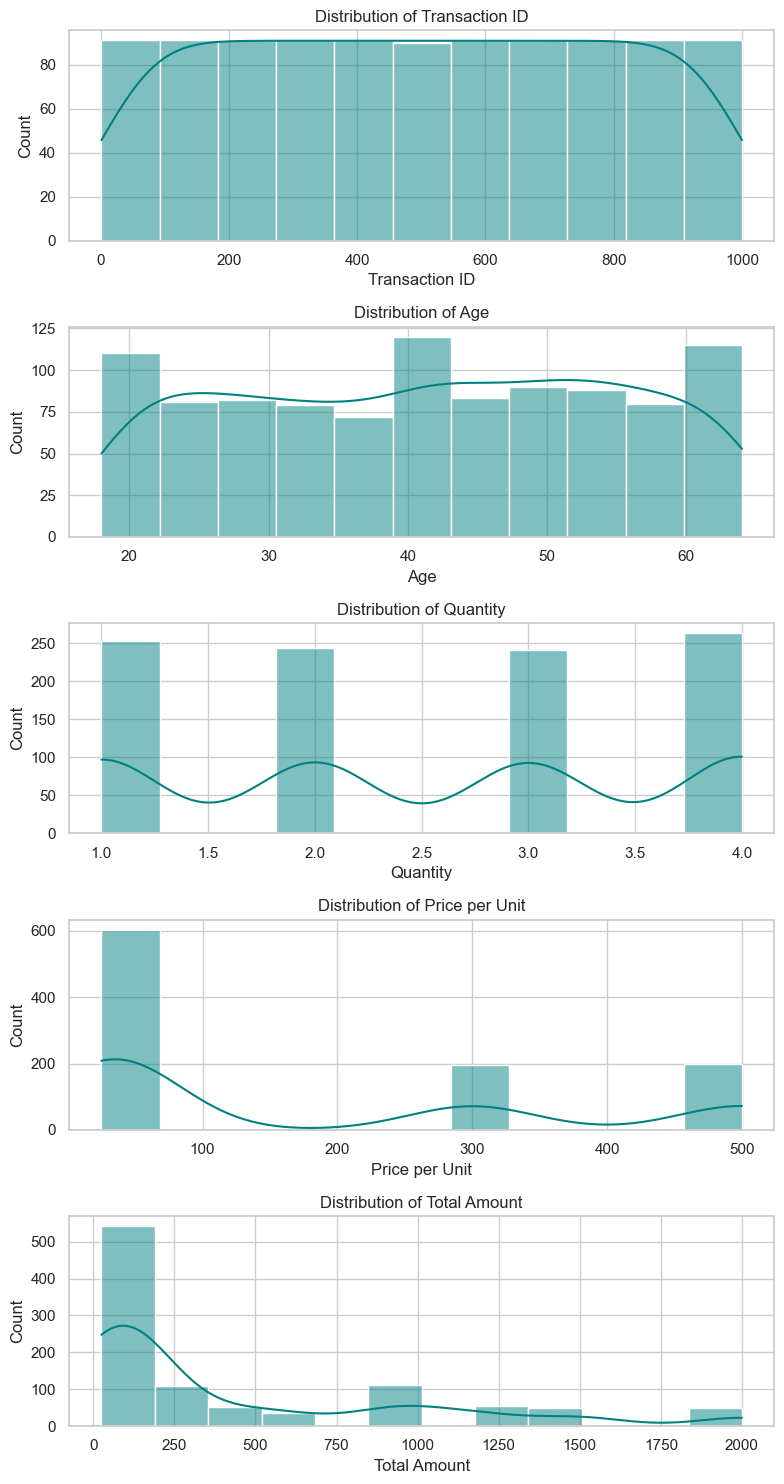

In [5]:
# Histograms with density (KDE) for numerical columns
num_cols = df.select_dtypes(include=["number"]).columns
fig, axes = plt.subplots(len(num_cols), 1, figsize=(8, 3 * len(num_cols)))
if len(num_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="teal")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_12964\38952366.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Product Category", y="Total Amount", ax=axes[0], palette="Pastel1")
C:\Users\admin\AppData\Local\Temp\ipykernel_12964\38952366.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Gender", y="Total Amount", ax=axes[1], palette="Pastel2")


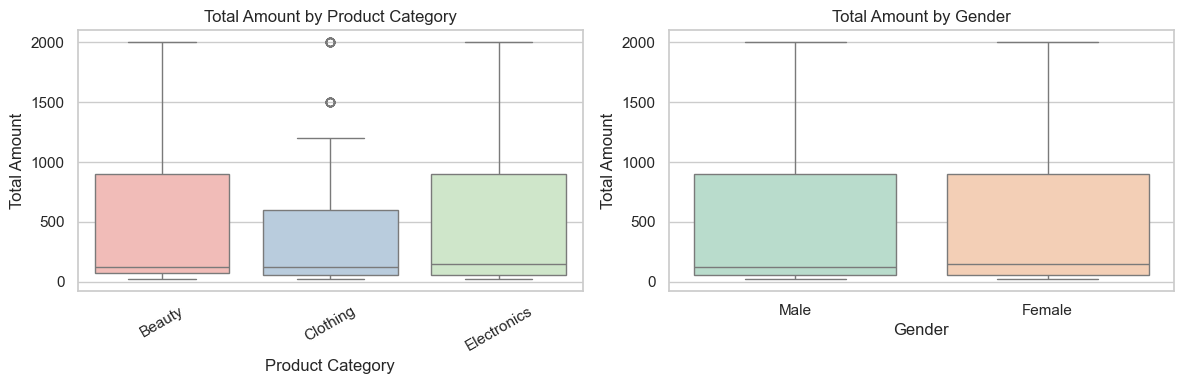

In [6]:
# Boxplots to visualize distributions and outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="Product Category", y="Total Amount", ax=axes[0], palette="Pastel1")
axes[0].set_title("Total Amount by Product Category")
axes[0].tick_params(axis="x", rotation=30)
sns.boxplot(data=df, x="Gender", y="Total Amount", ax=axes[1], palette="Pastel2")
axes[1].set_title("Total Amount by Gender")
plt.tight_layout()
plt.show()

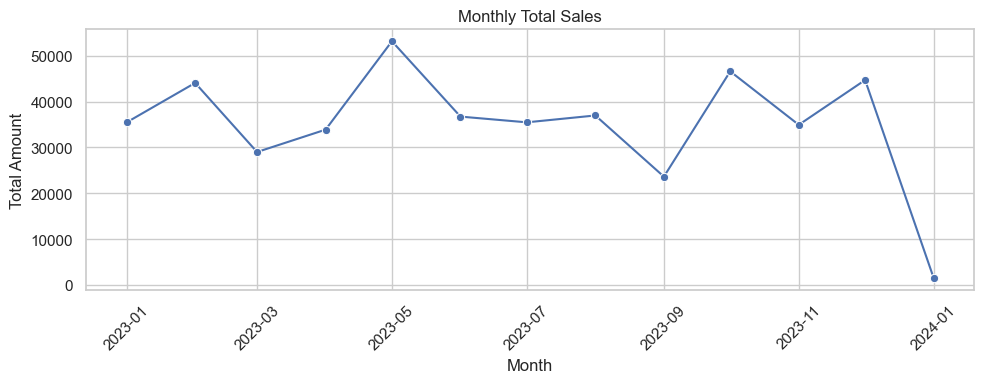

In [7]:
# Time series plot (monthly total sales)
ts = df.dropna(subset=["Date"]).copy()
ts["YearMonth"] = ts["Date"].dt.to_period("M").dt.to_timestamp()
monthly_sales = ts.groupby("YearMonth")["Total Amount"].sum().reset_index()
plt.figure(figsize=(10, 4))
sns.lineplot(data=monthly_sales, x="YearMonth", y="Total Amount", marker="o")
plt.title("Monthly Total Sales")
plt.xlabel("Month")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

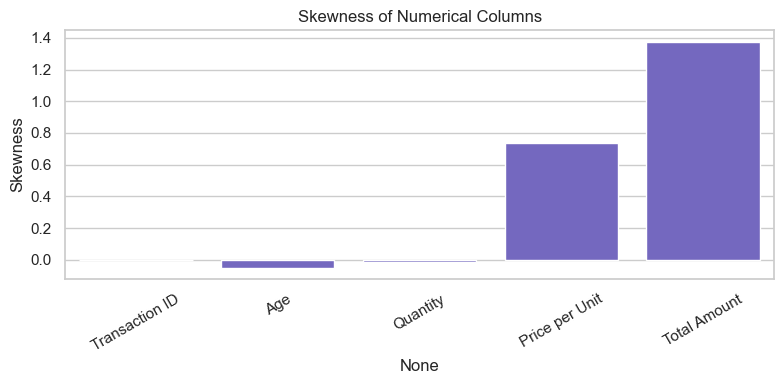

In [8]:
# Skewness values for numerical columns
skew_vals = df[num_cols].skew()
plt.figure(figsize=(8, 4))
sns.barplot(x=skew_vals.index, y=skew_vals.values, color="slateblue")
plt.title("Skewness of Numerical Columns")
plt.ylabel("Skewness")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

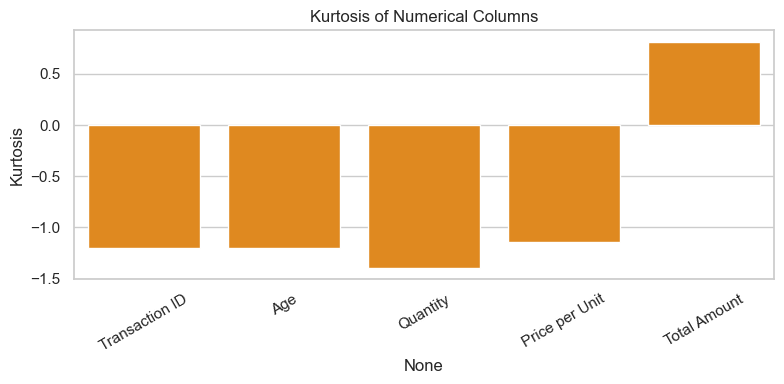

In [9]:
# Kurtosis values for numerical columns
kurt_vals = df[num_cols].kurt()
plt.figure(figsize=(8, 4))
sns.barplot(x=kurt_vals.index, y=kurt_vals.values, color="darkorange")
plt.title("Kurtosis of Numerical Columns")
plt.ylabel("Kurtosis")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

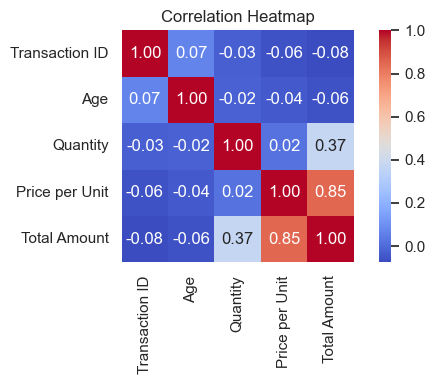

In [10]:
# Correlation heatmap
corr = df[num_cols].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_12964\1297562224.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df, x="Product Category", y="Total Amount", kind="bar", height=4, aspect=1.5, palette="Set2")


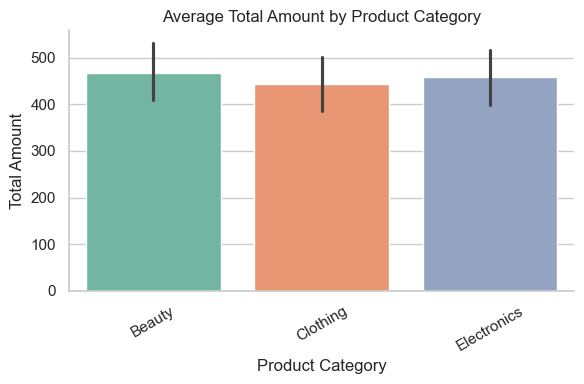

In [11]:
# Catplot (factorplot)
sns.catplot(data=df, x="Product Category", y="Total Amount", kind="bar", height=4, aspect=1.5, palette="Set2")
plt.title("Average Total Amount by Product Category")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

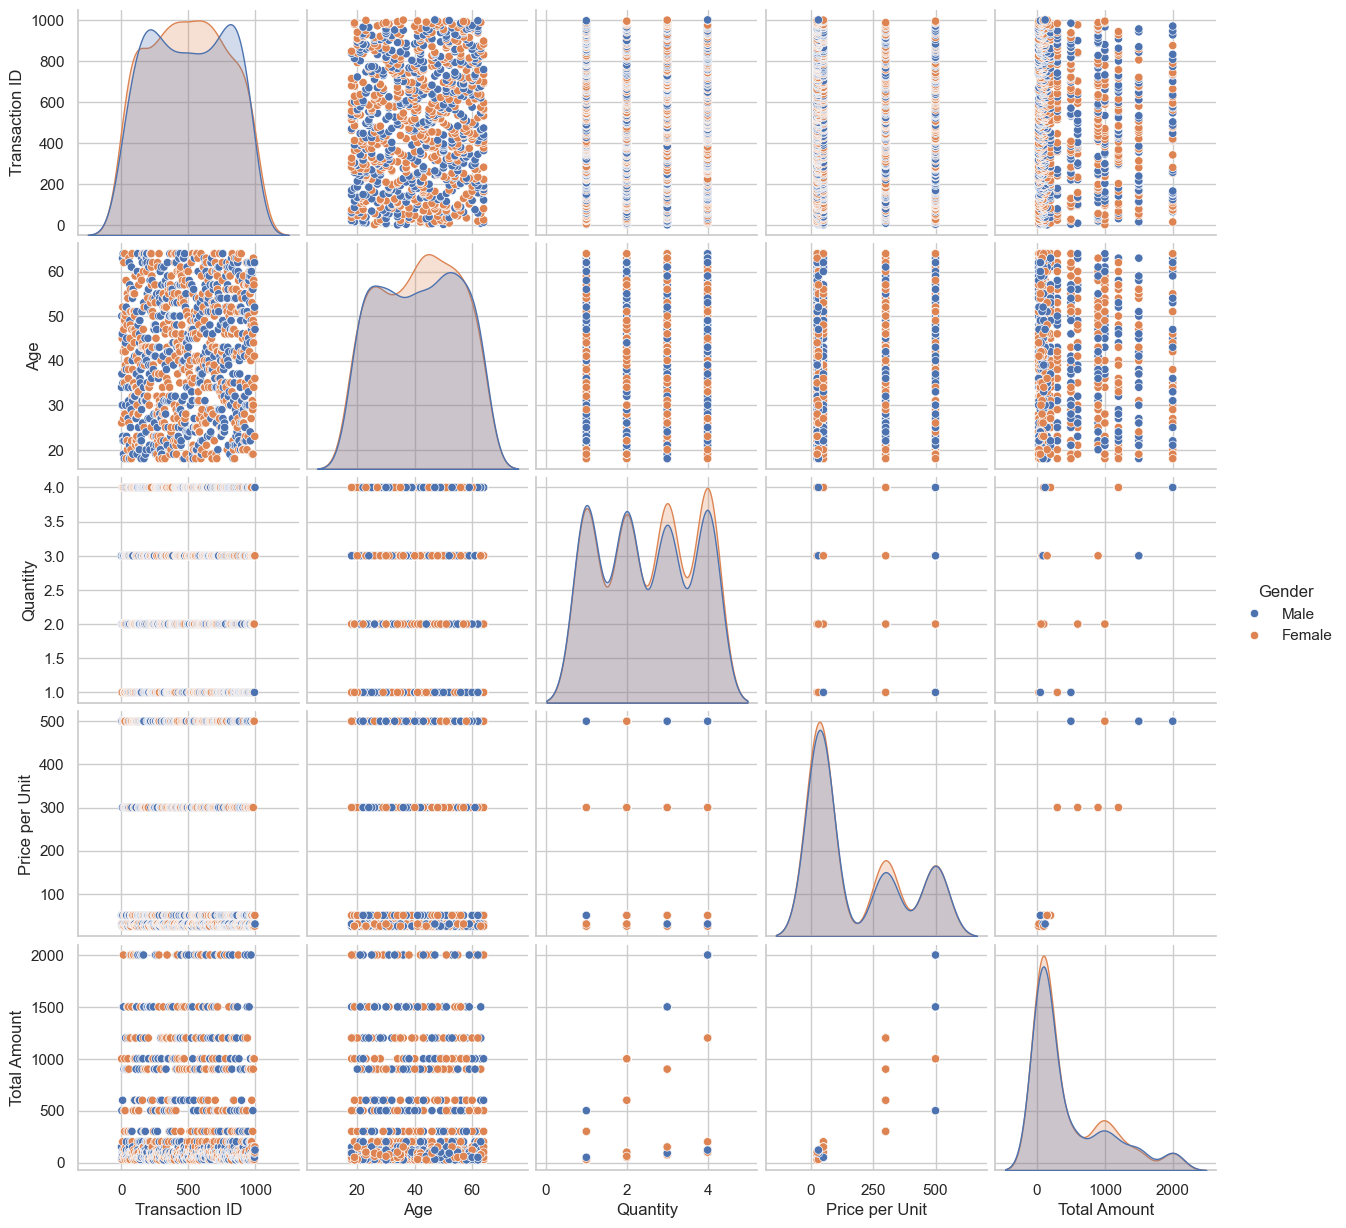

In [12]:
# Pairplot for numerical variables
sns.pairplot(df[num_cols.tolist() + ["Gender"]], hue="Gender", diag_kind="kde")
plt.show()

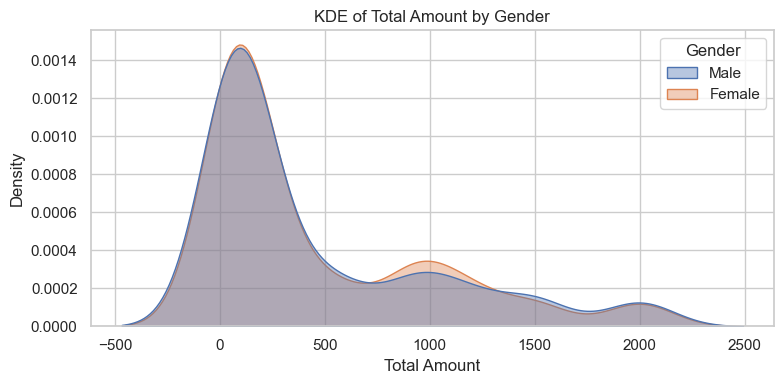

In [13]:
# KDE plot
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x="Total Amount", hue="Gender", fill=True, common_norm=False, alpha=0.4)
plt.title("KDE of Total Amount by Gender")
plt.tight_layout()
plt.show()

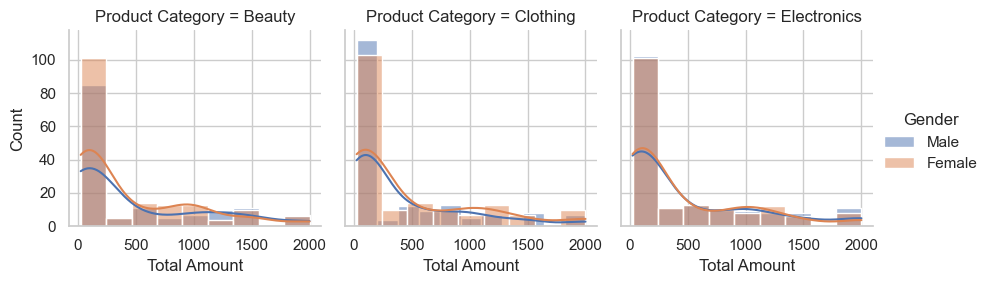

In [14]:
# FacetGrid example
g = sns.FacetGrid(df, col="Product Category", hue="Gender", height=3, aspect=1)
g.map_dataframe(sns.histplot, x="Total Amount", kde=True, alpha=0.5)
g.add_legend()
plt.show()

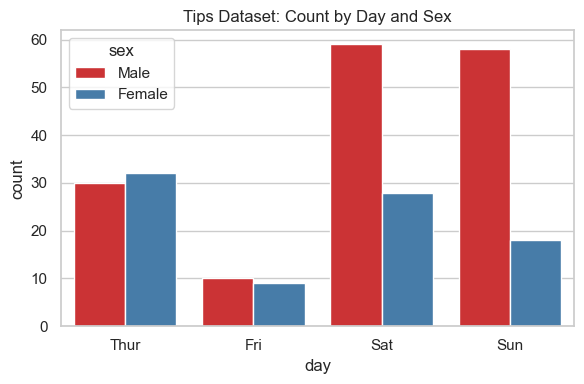

In [15]:
# Countplot on tips dataset
tips = sns.load_dataset("tips")
plt.figure(figsize=(6, 4))
sns.countplot(data=tips, x="day", hue="sex", palette="Set1")
plt.title("Tips Dataset: Count by Day and Sex")
plt.tight_layout()
plt.show()

## Conclusion
Thus we have studied and plotted various graphs for data visualization.